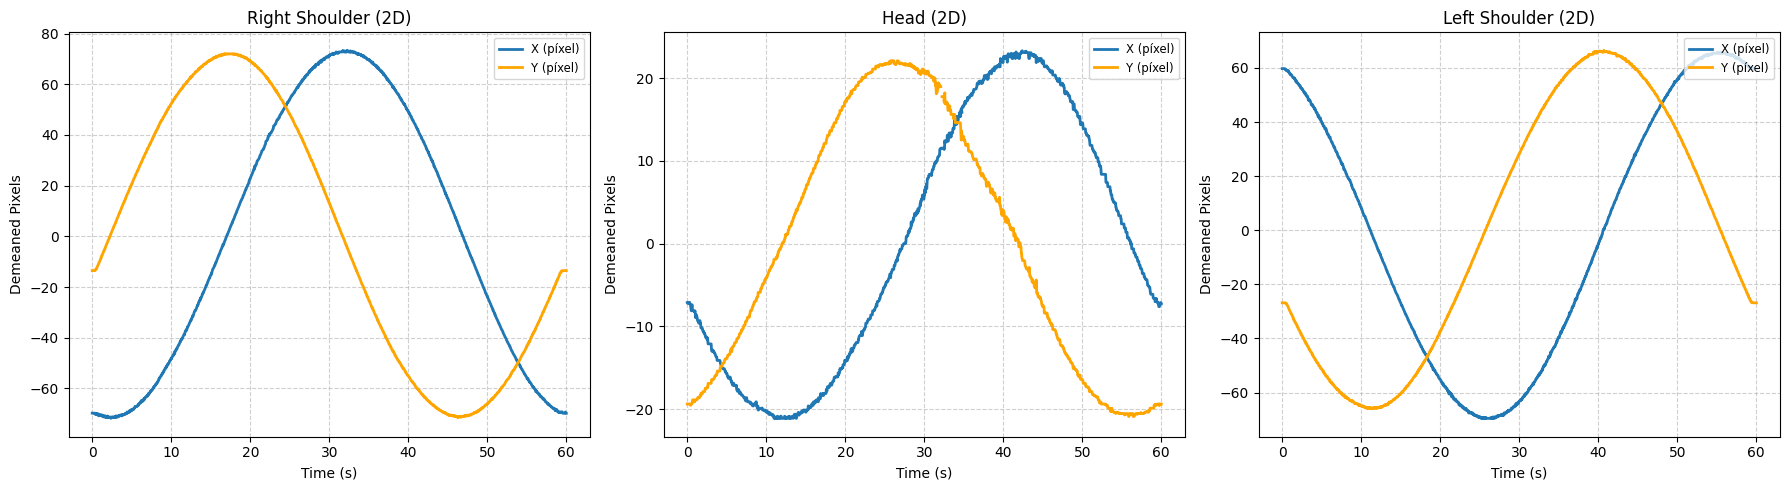

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = ("/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/box1/Output_processed/centers_2d.csv")
output_folder = "/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/box1/Output_processed/"


# -------------------------
# PLOTTING FUNCTION
# -------------------------
def plot_to_ax(ax, data, marker_pos):
    num_points = data.shape[0]
    t = np.linspace(0, 60, num_points)

    ax.plot(t, data[:, 0], label='X (píxel)', linewidth=2)
    ax.plot(t, data[:, 1], label='Y (píxel)', linewidth=2, color='orange')

    ax.set_ylabel('Demeaned Pixels')
    ax.set_xlabel('Time (s)')
    ax.set_title(f"{marker_pos} (2D)")
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)


# -------------------------
# LOAD DATA
# -------------------------

raw_df = pd.read_csv(input_csv)

left_shoulder = raw_df[['pt1_x', 'pt1_y']]
head = raw_df[['pt2_x', 'pt2_y']]
right_shoulder = raw_df[['pt3_x', 'pt3_y']]

markers = [
    (left_shoulder, 'Right Shoulder', 'pt1'),
    (head, 'Head', 'pt2'),
    (right_shoulder, 'Left Shoulder', 'pt3')
]

# -------------------------
# CREATE SUBPLOTS
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, name, prefix) in zip(axes, markers):
    x = df[f'{prefix}_x']
    y = df[f'{prefix}_y']

    x_norm = x - x.mean()
    y_norm = y - y.mean()

    # CANVI: Stack només de 2 columnes
    data = np.vstack((x_norm, y_norm)).T

    plot_to_ax(ax, data, name)

plt.tight_layout()
# CANVI: Nou nom de fitxer per no sobreescriure el 3D
save_path = os.path.join(output_folder, 'markers_2d_normalized.png')
plt.savefig(save_path, dpi=200)
plt.show()


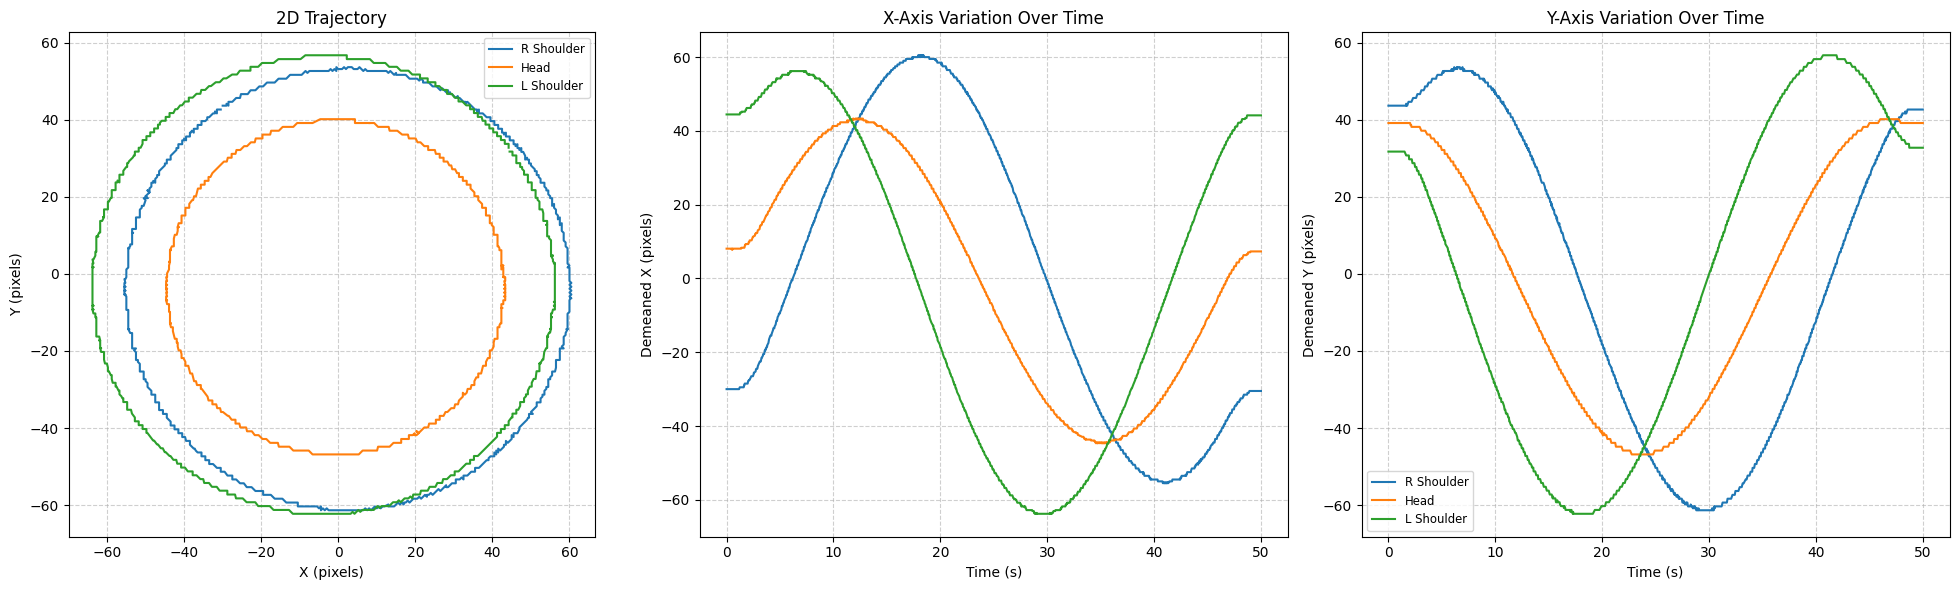

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar dades (centers_2d.csv)
input_csv = "/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/2201/Output_processed/centers_2d.csv"
df = pd.read_csv(input_csv).interpolate(method='linear').reset_index(drop=True)

# Crear eix de temps (estimat de 0 a 50 segons)
time = np.linspace(0, 50, len(df))

# 2. Setup Figure: 1 fila, 3 columnes
fig, (ax_spatial, ax_x_t, ax_y_t) = plt.subplots(1, 3, figsize=(20, 6))

# 3. Plot de cada marcador
markers_info = [('pt1', 'R Shoulder'), ('pt2', 'Head'), ('pt3', 'L Shoulder')]

for pt, label in markers_info:
    # Normalitzem restant la mitjana per centrar el moviment a (0,0)
    x = df[f'{pt}_x'] - df[f'{pt}_x'].mean()
    y = df[f'{pt}_y'] - df[f'{pt}_y'].mean()

    # Subplot 1: Vista "Frontal" de la imatge (X vs Y)
    ax_spatial.plot(x, y, label=label)

    # Subplot 2: Evolució de X en el temps (Oscil·lació del gir)
    ax_x_t.plot(time, x, label=label)

    # Subplot 3: Evolució de Y en el temps (Estabilitat vertical)
    ax_y_t.plot(time, y, label=label)

# -------------------------
# FORMATTING
# -------------------------

# Gràfic Espacial 2D
ax_spatial.set_xlabel('X (pixels)')
ax_spatial.set_ylabel('Y (pixels)')
ax_spatial.set_aspect('equal', adjustable='box')
ax_spatial.set_title('2D Trajectory')
ax_spatial.grid(True, linestyle='--', alpha=0.6)
ax_spatial.legend(fontsize='small')

# Gràfic X vs Temps
ax_x_t.set_xlabel('Time (s)')
ax_x_t.set_ylabel('Demeaned X (pixels)')
ax_x_t.set_title('X-Axis Variation Over Time')
ax_x_t.grid(True, linestyle='--', alpha=0.6)

# Gràfic Y vs Temps
ax_y_t.set_xlabel('Time (s)')
ax_y_t.set_ylabel('Demeaned Y (píxels)')
ax_y_t.set_title('Y-Axis Variation Over Time')
ax_y_t.grid(True, linestyle='--', alpha=0.6)
ax_y_t.legend(fontsize='small')

plt.tight_layout()
plt.show()

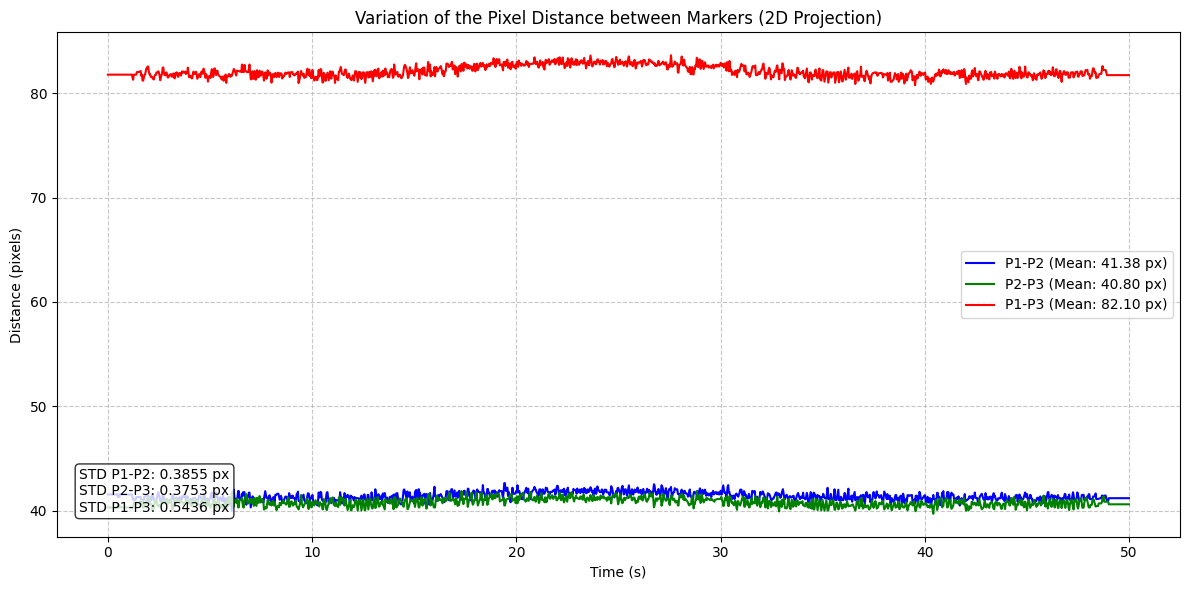

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/2201/Output_processed/centers_2d.csv"
output_folder = "/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/box1/Output_processed/"

df = pd.read_csv(input_csv).interpolate(method='linear').reset_index(drop=True)
time = np.linspace(0, 50, len(df))

# -------------------------
# Distància Euclidiana 2D
# -------------------------
def calculate_distance_2d(p1, p2):
    # sqrt((x2-x1)^2 + (y2-y1)^2)
    return np.sqrt((p1[:,0] - p2[:,0])**2 + (p1[:,1] - p2[:,1])**2)

p1 = df[['pt1_x', 'pt1_y']].to_numpy()
p2 = df[['pt2_x', 'pt2_y']].to_numpy()
p3 = df[['pt3_x', 'pt3_y']].to_numpy()

dist_1_2 = calculate_distance_2d(p1, p2)
dist_2_3 = calculate_distance_2d(p2, p3)
dist_1_3 = calculate_distance_2d(p1, p3)

# -------------------------
# Plot de la variació de distància
# -------------------------
plt.figure(figsize=(12, 6))

plt.plot(time, dist_1_2, label=f'P1-P2 (Mean: {dist_1_2.mean():.2f} px)', color='blue')
plt.plot(time, dist_2_3, label=f'P2-P3 (Mean: {dist_2_3.mean():.2f} px)', color='green')
plt.plot(time, dist_1_3, label=f'P1-P3 (Mean: {dist_1_3.mean():.2f} px)', color='red')

plt.title('Variation of the Pixel Distance between Markers (2D Projection)')
plt.xlabel('Time (s)')
plt.ylabel('Distance (pixels)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

info_text = (f"STD P1-P2: {dist_1_2.std():.4f} px\n"
             f"STD P2-P3: {dist_2_3.std():.4f} px\n"
             f"STD P1-P3: {dist_1_3.std():.4f} px")
plt.annotate(info_text, xy=(0.02, 0.05), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.tight_layout()
save_path_dist = os.path.join(output_folder, 'marker_distances_2d.png')
plt.savefig(save_path_dist, dpi=200)
plt.show()


In [75]:
import pandas as pd

dades = {
    "Configuration": [
        "infrareds on wood 50cm",
        "infrareds on wood 70cm",
        "infrareds on wood 90cm",
        "infrareds on wood 220cm",
        "infrareds on platform 240cm",
        "infrareds on box 65cm"
    ],
    "STD P1-P2 (px)": [7.1678, 3.4062, 0.8997, 0.1770, 0.3591, 0.6802],
    "STD P2-P3 (px)": [10.9653, 2.7635, 1.4984, 0.3547, 0.3057, 0.9225],
    "STD P1-P3 (px)": [5.8110, 5.4674, 2.2409, 0.4402, 0.3380, 0.9523]
}

df = pd.DataFrame(dades)

print("Error of the camera without depth (extracting data from centers_2d.csv):")
print("=" * 33)
print(df.to_string(index=False))

Error of the camera without depth (extracting data from centers_2d.csv):
              Configuration  STD P1-P2 (px)  STD P2-P3 (px)  STD P1-P3 (px)
     infrareds on wood 50cm          7.1678         10.9653          5.8110
     infrareds on wood 70cm          3.4062          2.7635          5.4674
     infrareds on wood 90cm          0.8997          1.4984          2.2409
    infrareds on wood 220cm          0.1770          0.3547          0.4402
infrareds on platform 240cm          0.3591          0.3057          0.3380
      infrareds on box 65cm          0.6802          0.9225          0.9523


In [1]:
import pandas as pd

# 1. Define the original 2D data (in pixels) from your image
data_px = {
    "Configuration": [
        "infrareds on wood 50cm",
        "infrareds on wood 70cm",
        "infrareds on wood 90cm",
        "infrareds on wood 220cm",
        "infrareds on platform 240cm",
        "infrareds on box 65cm"
    ],
    "STD P1-P2 (px)": [7.1678, 3.4062, 0.8997, 0.1770, 0.3591, 0.6802],
    "STD P2-P3 (px)": [10.9653, 2.7635, 1.4984, 0.3547, 0.3057, 0.9225],
    "STD P1-P3 (px)": [5.8110, 5.4674, 2.2409, 0.4402, 0.3380, 0.9523]
}

# Create initial DataFrame
df_px = pd.DataFrame(data_px)

# 2. Conversion factor calculation
# Given: 5 px = 10 mm -> 1 px = 2 mm
conversion_factor = 2.0

# 3. Create the new converted DataFrame (in mm)
df_mm = pd.DataFrame()
df_mm["Configuration"] = df_px["Configuration"]

# Multiply only the numeric pixel columns by 2
df_mm["STD P1-P2 (mm)"] = df_px["STD P1-P2 (px)"] * conversion_factor
df_mm["STD P2-P3 (mm)"] = df_px["STD P2-P3 (px)"] * conversion_factor
df_mm["STD P1-P3 (mm)"] = df_px["STD P1-P3 (px)"] * conversion_factor

# 4. Display the formatted result
print("=== Converted 2D Camera Error Table (in mm) ===")
print(df_mm.to_string(index=False, formatters={
    "STD P1-P2 (mm)": "{:.4f}".format,
    "STD P2-P3 (mm)": "{:.4f}".format,
    "STD P1-P3 (mm)": "{:.4f}".format
}))

=== Converted 2D Camera Error Table (in mm) ===
              Configuration STD P1-P2 (mm) STD P2-P3 (mm) STD P1-P3 (mm)
     infrareds on wood 50cm        14.3356        21.9306        11.6220
     infrareds on wood 70cm         6.8124         5.5270        10.9348
     infrareds on wood 90cm         1.7994         2.9968         4.4818
    infrareds on wood 220cm         0.3540         0.7094         0.8804
infrareds on platform 240cm         0.7182         0.6114         0.6760
      infrareds on box 65cm         1.3604         1.8450         1.9046


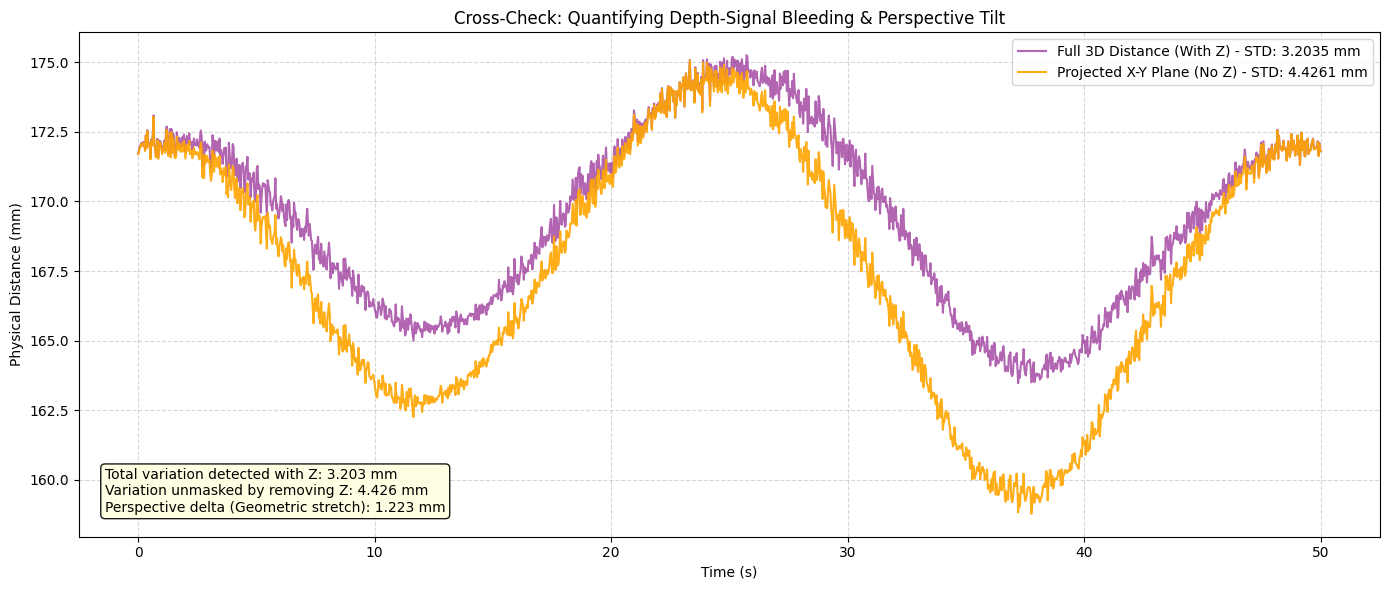

In [60]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. LOAD 3D DATA
input_3d_csv = "/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/box1/Output_processed/points_3d.csv"
df_3d = pd.read_csv(input_3d_csv).interpolate(method="linear").reset_index(drop=True)
time = np.linspace(0, 50, len(df_3d))

# Extract X, Y, Z coordinates for P1 and P3 in millimeters
p1_x, p1_y, p1_z = (
    df_3d["pt1_x"].to_numpy(),
    df_3d["pt1_y"].to_numpy(),
    df_3d["pt1_z"].to_numpy(),
)
p3_x, p3_y, p3_z = (
    df_3d["pt3_x"].to_numpy(),
    df_3d["pt3_y"].to_numpy(),
    df_3d["pt3_z"].to_numpy(),
)

# 2. CALCULATION 1: Full 3D Distance (Includes ToF depth noise jitter)
dist_3d_completa = np.sqrt((p3_x - p1_x) ** 2 + (p3_y - p1_y) ** 2 + (p3_z - p1_z) ** 2)

# 3. CALCULATION 2: Projected X-Y Plane (Boris Cross-check: sqrt(dX^2 + dY^2) ignoring Z)
dx = p3_x - p1_x
dy = p3_y - p1_y
dist_projeccio_xy = np.sqrt(dx**2 + dy**2)

# 4. COMPARATIVE PLOT
plt.figure(figsize=(14, 6))

plt.plot(
    time,
    dist_3d_completa,
    label=f"Full 3D Distance (With Z) - STD: {dist_3d_completa.std():.4f} mm",
    color="purple",
    alpha=0.6,
)
plt.plot(
    time,
    dist_projeccio_xy,
    label=f"Projected X-Y Plane (No Z) - STD: {dist_projeccio_xy.std():.4f} mm",
    color="orange",
    alpha=0.9,
)

plt.title("Cross-Check: Quantifying Depth-Signal Bleeding & Perspective Tilt")
plt.xlabel("Time (s)")
plt.ylabel("Physical Distance (mm)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")

# Metric data text box
conclusions_text = (
    f"Total variation detected with Z: {dist_3d_completa.std():.3f} mm\n"
    f"Variation unmasked by removing Z: {dist_projeccio_xy.std():.3f} mm\n"
    f"Perspective delta (Geometric stretch): {dist_projeccio_xy.std() - dist_3d_completa.std():.3f} mm"
)
plt.annotate(
    conclusions_text,
    xy=(0.02, 0.05),
    xycoords="axes fraction",
    bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.9),
)

plt.tight_layout()
plt.show()

In [88]:
import pandas as pd
import numpy as np

# 1. CARREGAR LES DADES 3D
input_3d_csv = "/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/box1/Output_processed/transform_3d.csv"
df_3d = pd.read_csv(input_3d_csv).interpolate(method='linear').reset_index(drop=True)

p1 = df_3d[['pt1_x', 'pt1_y', 'pt1_z']].to_numpy()
p2 = df_3d[['pt2_x', 'pt2_y', 'pt2_z']].to_numpy()
p3 = df_3d[['pt3_x', 'pt3_y', 'pt3_z']].to_numpy()

# 2. FUNCIONS DE DISTÀNCIA
def dist_3d(pa, pb):
    # sqrt((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)
    return np.sqrt((pa[:,0]-pb[:,0])**2 + (pa[:,1]-pb[:,1])**2 + (pa[:,2]-pb[:,2])**2)

def dist_2d_proj(pa, pb):
    # sqrt((x2-x1)^2 + (y2-y1)^2) -> Ignoring completely Z
    return np.sqrt((pa[:,0]-pb[:,0])**2 + (pa[:,1]-pb[:,1])**2)

parells = [
    ('P1-P2', p1, p2),
    ('P2-P3', p2, p3),
    ('P1-P3', p1, p3)
]

rand_data = []

# 3. CÀLCUL EN BUCLE PER A CADA PARELL
for nom, pa, pb in parells:
    # Calcular vectors de distància temporal
    d_3d = dist_3d(pa, pb)
    d_2d = dist_2d_proj(pa, pb)

    #STD
    std_3d_val = d_3d.std()
    std_2d_val = d_2d.std()
    bleed_val = abs(std_3d_val - std_2d_val)

    rand_data.append({
        "Configuration": nom,
        "Full 3D STD (mm)": round(std_3d_val, 4),
        "Flat 2D Proj STD (mm)": round(std_2d_val, 4),
        "Depth Bleed Impact (mm)": round(bleed_val, 4)
    })

# 4. CREAR I MOSTRAR LA TAULA
df_resultats = pd.DataFrame(rand_data)

print("\n=== CROSSED-CHECK RIGID BODY VARIANCE ===")
print(df_resultats.to_string(index=False))


=== CROSSED-CHECK RIGID BODY VARIANCE ===
Configuration  Full 3D STD (mm)  Flat 2D Proj STD (mm)  Depth Bleed Impact (mm)
        P1-P2            2.6132                 2.8105                   0.1974
        P2-P3            2.4343                 2.4346                   0.0003
        P1-P3            2.8835                 3.1385                   0.2550


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the 3D data
input_3d_csv = ("/Users/albamoline/Desktop/TFG/STUDY MOTION/RecordingsMariona/501/Output_processed/transform_3d.csv")
df_3d = pd.read_csv(input_3d_csv).interpolate(method='linear').reset_index(drop=True)

# Extract coordinates
p1_3d = df_3d[['pt1_x', 'pt1_y', 'pt1_z']].to_numpy()
p2_3d = df_3d[['pt2_x', 'pt2_y', 'pt2_z']].to_numpy()
p3_3d = df_3d[['pt3_x', 'pt3_y', 'pt3_z']].to_numpy()

# 1. Full 3D Distance (includes depth)
def dist_3d(pa, pb):
    return np.sqrt((pa[:,0]-pb[:,0])**2 + (pa[:,1]-pb[:,1])**2 + (pa[:,2]-pb[:,2])**2)

# 2. 2D Physical Projection (ignoring depth/Z channel)
def dist_2d_proj(pa, pb):
    return np.sqrt((pa[:,0]-pb[:,0])**2 + (pa[:,1]-pb[:,1])**2)

# Calculate metrics for P1-P2 as an example
d_3d_12 = dist_3d(p1_3d, p2_3d)
d_2d_proj_12 = dist_2d_proj(p1_3d, p2_3d)

# Calculate standard deviations
std_3d = d_3d_12.std()
std_2d_proj = d_2d_proj_12.std()
depth_bleed = abs(std_3d - std_2d_proj)

print(f"--- Rigid Body Check: P1 to P2 ---")
print(f"Full 3D STD (Physical Error): {std_3d:.4f} mm")
print(f"Flat 2D Projection STD (Ignoring Z): {std_2d_proj:.4f} mm")
print(f"Depth signal 'bleeding' variance impact: {depth_bleed:.4f} mm")

--- Rigid Body Check: P1 to P2 ---
Full 3D STD (Physical Error): 7.0671 mm
Flat 2D Projection STD (Ignoring Z): 7.1969 mm
Depth signal 'bleeding' variance impact: 0.1298 mm
